# Prepare Local Database for Router Training

This notebook fetches all profiling data from PostgreSQL once and saves it to a local SQLite database.

## Purpose

Instead of hitting the remote PostgreSQL database every time you run a training notebook:
1. **Run this notebook ONCE** to download all data
2. Data is saved as a local SQLite file (`../data/vlm_router_cache.db`)
3. **Other notebooks load from local SQLite** - much faster!

## Benefits

✅ **Faster iterations** - No network latency  
✅ **Work offline** - No need for database connection  
✅ **Consistent data** - All notebooks use same snapshot  
✅ **No database load** - Don't stress production database  

## Output

Creates `../data/vlm_router_cache.db` with:
- All profiling data from PostgreSQL
- Data validation and cleaning applied
- Ready to use in notebooks 02, 03, 04

## 1. Setup

In [1]:
# Add parent directory to path
import sys
import os
sys.path.insert(0, os.path.dirname(os.getcwd()))

import logging
from pathlib import Path
from datetime import datetime

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Local imports
from config import DBConfig
from db_utils import (
    load_profiles_real_schema,
    test_connection,
    save_to_sqlite,
    load_from_sqlite,
)
from training.data_validation import (
    validate_profiles_dataframe,
    clean_profiles_dataframe,
    validate_train_val_test_split,
)

# Configure logging
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(name)s - %(levelname)s - %(message)s'
)
logger = logging.getLogger(__name__)

# Plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ Imports successful")

✓ Imports successful


In [2]:
# Configuration
DATA_DIR = Path("../data")
DATA_DIR.mkdir(exist_ok=True)

# Output database path
LOCAL_DB_PATH = DATA_DIR / "vlm_router_cache.db"
TABLE_NAME = "vlm_profiles"

# How much data to fetch (None = all data)
LIMIT = 50  # Set to e.g. 10000 for testing
LIMIT_PER_SPLIT = True  # Apply the limit per data_split

print("Configuration:")
print(f"  Local DB Path: {LOCAL_DB_PATH}")
print(f"  Table Name: {TABLE_NAME}")
print(f"  Limit: {LIMIT}")
print(f"  Limit per split: {LIMIT_PER_SPLIT}")

Configuration:
  Local DB Path: ../data/vlm_router_cache.db
  Table Name: vlm_profiles
  Limit: 50
  Limit per split: True


## 2. Connect to PostgreSQL

In [3]:
# Load database configuration from environment
db_config = DBConfig.from_env()

print("[PostgreSQL Configuration]")
print(f"  Host: {db_config.host}")
print(f"  Port: {db_config.port}")
print(f"  Database: {db_config.name}")
print(f"  User: {db_config.user}")

# Test connection
print("\n[Testing Connection]")
if test_connection(db_config):
    print("✓ PostgreSQL connection successful!")
else:
    raise RuntimeError("PostgreSQL connection failed. Check credentials and network.")

2025-12-06 16:41:26,875 - db_utils - INFO - Created database engine for localhost:5432/vlmrouter
2025-12-06 16:41:26,914 - db_utils - INFO - Database connection test successful


[PostgreSQL Configuration]
  Host: localhost
  Port: 5432
  Database: vlmrouter
  User: vlmrouter

[Testing Connection]
✓ PostgreSQL connection successful!


## 3. Fetch All Data from PostgreSQL

In [4]:
# Load all data (no data_split filter)
print(f"\n{'='*80}")
print("FETCHING DATA FROM POSTGRESQL")
print(f"{'='*80}\n")

print("[Loading Profiling Data]")
print(f"  Source: PostgreSQL ({db_config.host}:{db_config.port}/{db_config.name})")
print(f"  Limit: {LIMIT if LIMIT else 'None (all data)'}")
print(f"  Limit per split: {LIMIT_PER_SPLIT}")
print(f"  Tables: vlm_samples, vlm_responses, vlm_evaluations, vlm_images")
print()

df_all = load_profiles_real_schema(
    db_config=db_config,
    limit=LIMIT,
    data_split=None,  # Load ALL splits
    limit_per_split=LIMIT_PER_SPLIT,
)

print(f"\n[Data Loaded]")
print(f"  Total rows: {len(df_all):,}")
print(f"  Unique samples: {df_all['sample_id'].nunique():,}")
print(f"  Unique models: {df_all['model_name'].nunique()}")
print(f"  Columns: {len(df_all.columns)}")

if 'data_split' in df_all.columns:
    print(f"\n  Data split distribution:")
    for split, count in df_all['data_split'].value_counts().items():
        pct = 100 * count / len(df_all)
        print(f"    {split:6s}: {count:7,} ({pct:5.2f}%)")

2025-12-06 16:41:26,921 - db_utils - INFO - Created database engine for localhost:5432/vlmrouter
2025-12-06 16:41:26,921 - db_utils - INFO - Loading profiling data from database (real schema)...
2025-12-06 16:41:26,922 - db_utils - INFO -   Limit: 50
2025-12-06 16:41:26,922 - db_utils - INFO -   Applying the limit per data_split/router_task partition



FETCHING DATA FROM POSTGRESQL

[Loading Profiling Data]
  Source: PostgreSQL (localhost:5432/vlmrouter)
  Limit: 50
  Limit per split: True
  Tables: vlm_samples, vlm_responses, vlm_evaluations, vlm_images



2025-12-06 16:41:27,046 - db_utils - INFO - Loaded 2218 profile records
2025-12-06 16:41:27,046 - db_utils - INFO -   Unique samples: 570
2025-12-06 16:41:27,047 - db_utils - INFO -   Unique models: 5
2025-12-06 16:41:27,047 - db_utils - INFO -   Source datasets: ['cauldron']
2025-12-06 16:41:27,048 - db_utils - INFO -   Router tasks: ['chart_captioning', 'chart_reasoning', 'code_generation', 'diagram_captioning', 'diagram_reasoning', 'document_ocr', 'general_vqa', 'geometry_reasoning', 'handwriting_ocr', 'icon_reasoning', 'knowledge_vqa', 'meme_classification', 'spatial_reasoning', 'table_math', 'table_reasoning']
2025-12-06 16:41:27,048 - db_utils - INFO -   Data splits: {'train': 750, 'test': 740, 'val': 728}
2025-12-06 16:41:27,049 - db_utils - INFO -   glider_score: 0/2218 (0.0%) missing
2025-12-06 16:41:27,049 - db_utils - INFO -   glider_score range: [0.00, 5.00]
2025-12-06 16:41:27,050 - db_utils - INFO -   cost_usd: 0 null, 0 zero
2025-12-06 16:41:27,050 - db_utils - INFO -   


[Data Loaded]
  Total rows: 2,218
  Unique samples: 570
  Unique models: 5
  Columns: 17

  Data split distribution:
    train :     750 (33.81%)
    test  :     740 (33.36%)
    val   :     728 (32.82%)


In [5]:
# Preview data
print("[Data Preview]\n")
display(df_all.head())

print("\n[Data Info]")
print(df_all.info())

[Data Preview]



,sample_id,source_config,source_dataset,router_task,data_split,prompt_raw,txt_prompt_length_chars,txt_prompt_length_words,img_width,img_height,img_aspect_ratio,model_name,model_prefix,latency_ms,cost_usd,confidence_score,glider_score
0,chart2text_0_68249402,chart2text,cauldron,chart_captioning,test,Could you shed some light on the insights conv...,65,12,800,776,1.030928,qwen2_5_vl_7b,m3,8598.0,0.000246,0.760264,4.0
1,chart2text_0_68249402,chart2text,cauldron,chart_captioning,test,Could you shed some light on the insights conv...,65,12,800,776,1.030928,gemma_3_27b,m5,10272.0,0.000097,0.832087,5.0
2,chart2text_0_68249402,chart2text,cauldron,chart_captioning,test,Could you shed some light on the insights conv...,65,12,800,776,1.030928,deepseek_ocr,m1,1254.0,0.000037,0.996436,0.0
3,chart2text_0_68249402,chart2text,cauldron,chart_captioning,test,Could you shed some light on the insights conv...,65,12,800,776,1.030928,qwen3_vl_8b_thinking,m4,5033.0,0.001188,0.865371,4.0
4,chart2text_0_68249402,chart2text,cauldron,chart_captioning,test,Could you shed some light on the insights conv...,65,12,800,776,1.030928,qwen2_5_vl_3b,m2,6152.0,0.000098,0.831460,4.0



[Data Info]
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2218 entries, 0 to 2217
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   sample_id                2218 non-null   object 
 1   source_config            2218 non-null   object 
 2   source_dataset           2218 non-null   object 
 3   router_task              2218 non-null   object 
 4   data_split               2218 non-null   object 
 5   prompt_raw               2218 non-null   object 
 6   txt_prompt_length_chars  2218 non-null   int64  
 7   txt_prompt_length_words  2218 non-null   int64  
 8   img_width                2218 non-null   int64  
 9   img_height               2218 non-null   int64  
 10  img_aspect_ratio         2218 non-null   float64
 11  model_name               2218 non-null   object 
 12  model_prefix             2218 non-null   object 
 13  latency_ms               2218 non-null   float64
 14  cost_usd   

## 4. Validate and Clean Data

In [6]:
# Validate data quality
print(f"\n{'='*80}")
print("DATA VALIDATION")
print(f"{'='*80}\n")

validation_report = validate_profiles_dataframe(
    df=df_all,
    allow_missing_images=True,
    allow_missing_confidence=True,
    max_missing_cost_pct=10.0,
    max_missing_latency_pct=10.0,
    max_missing_glider_pct=5.0,
)

print(f"\n{'='*80}")
print("VALIDATION REPORT")
print(f"{'='*80}")
print(f"  Total rows: {validation_report['total_rows']:,}")
print(f"  Validation passed: {validation_report['validation_passed']}")
print(f"  Errors: {len(validation_report['errors'])}")
print(f"  Warnings: {len(validation_report['warnings'])}")

if validation_report['errors']:
    print(f"\n  Errors:")
    for error in validation_report['errors']:
        print(f"    ❌ {error}")

if validation_report['warnings']:
    print(f"\n  Warnings (showing first 10):")
    for warning in validation_report['warnings'][:10]:
        print(f"    ⚠️  {warning}")

print(f"\n  Statistics:")
for key, value in validation_report['statistics'].items():
    if isinstance(value, dict):
        print(f"    {key}: {value}")
    elif isinstance(value, float):
        print(f"    {key}: {value:.2f}")
    else:
        print(f"    {key}: {value}")
print(f"{'='*80}")

if not validation_report['validation_passed']:
    print("\n⚠️  Data validation found critical issues. Review errors above.")
    print("    You may need to adjust validation thresholds or fix data quality.")

2025-12-06 16:41:27,071 - training.data_validation - INFO - ✓ Data validation PASSED



DATA VALIDATION


VALIDATION REPORT
  Total rows: 2,218
  Validation passed: True
  Errors: 0
  Warnings: 0

  Statistics:
    cost_usd_missing_pct: 0.00
    latency_ms_missing_pct: 0.00
    glider_score_missing_pct: 0.00
    img_metadata_missing_pct: 0.00
    confidence_missing_pct: 0.00
    unique_samples: 570
    unique_models: 5
    data_split_counts: {'train': 750, 'test': 740, 'val': 728}


In [7]:
# Clean data
print(f"\n{'='*80}")
print("DATA CLEANING")
print(f"{'='*80}\n")

df_clean, cleaning_stats = clean_profiles_dataframe(
    df=df_all,
    fill_missing_cost=True,
    fill_missing_latency=True,
    fill_missing_confidence=True,
    drop_missing_glider=True,
    drop_duplicates=True,
)

print(f"\n{'='*80}")
print("CLEANING SUMMARY")
print(f"{'='*80}")
print(f"  Initial rows:        {cleaning_stats['initial_rows']:,}")
print(f"  Final rows:          {cleaning_stats['final_rows']:,}")
print(f"  Dropped rows:        {cleaning_stats['dropped_rows']:,} ({100*cleaning_stats['dropped_rows']/cleaning_stats['initial_rows']:.2f}%)")

if 'dropped_duplicates' in cleaning_stats:
    print(f"\n  Dropped duplicates:  {cleaning_stats['dropped_duplicates']:,}")
if 'dropped_missing_glider' in cleaning_stats:
    print(f"  Dropped missing glider: {cleaning_stats['dropped_missing_glider']:,}")
if 'filled_cost' in cleaning_stats:
    print(f"  Filled costs:        {cleaning_stats['filled_cost']:,}")
if 'filled_latency' in cleaning_stats:
    print(f"  Filled latencies:    {cleaning_stats['filled_latency']:,}")
if 'filled_confidence' in cleaning_stats:
    print(f"  Filled confidence:   {cleaning_stats['filled_confidence']:,}")
print(f"{'='*80}")

print(f"\n✓ Data cleaning complete")

2025-12-06 16:41:27,077 - training.data_validation - INFO - ✓ Data cleaning complete: 2218 → 2218 rows (0 dropped)



DATA CLEANING


CLEANING SUMMARY
  Initial rows:        2,218
  Final rows:          2,218
  Dropped rows:        0 (0.00%)
  Filled costs:        0
  Filled latencies:    0
  Filled confidence:   0

✓ Data cleaning complete


## 5. Validate Train/Val/Test Splits

In [8]:
# Check if we have train/val/test splits
if 'data_split' not in df_clean.columns:
    print("⚠️  Warning: 'data_split' column not found in data.")
    print("    Notebooks will need to create their own splits.")
else:
    print(f"\n{'='*80}")
    print("VALIDATING TRAIN/VAL/TEST SPLITS")
    print(f"{'='*80}\n")

    # Split into train/val/test
    train_df = df_clean[df_clean['data_split'] == 'train']
    val_df = df_clean[df_clean['data_split'] == 'val']
    test_df = df_clean[df_clean['data_split'] == 'test']

    print(f"Split sizes:")
    print(f"  Train: {len(train_df):,} rows")
    print(f"  Val:   {len(val_df):,} rows")
    print(f"  Test:  {len(test_df):,} rows")

    if len(train_df) > 0 and len(val_df) > 0 and len(test_df) > 0:
        # Validate split integrity
        split_stats = validate_train_val_test_split(
            train_df=train_df,
            val_df=val_df,
            test_df=test_df,
        )

        print(f"\n{'='*80}")
        print("SPLIT VALIDATION RESULTS")
        print(f"{'='*80}")
        print(f"  Train samples: {split_stats['train_samples']:,} ({split_stats['train_pct']:.1f}%)")
        print(f"  Val samples:   {split_stats['val_samples']:,} ({split_stats['val_pct']:.1f}%)")
        print(f"  Test samples:  {split_stats['test_samples']:,} ({split_stats['test_pct']:.1f}%)")
        print(f"\n  ✓ No data leakage detected between splits")
        print(f"{'='*80}")
    else:
        print("\n⚠️  Warning: Some splits are empty. Check data_split column values.")

2025-12-06 16:41:27,083 - training.data_validation - INFO - ✓ No data leakage detected between splits
2025-12-06 16:41:27,083 - training.data_validation - INFO - Split proportions: Train=33.9%, Val=32.8%, Test=33.3%



VALIDATING TRAIN/VAL/TEST SPLITS

Split sizes:
  Train: 750 rows
  Val:   728 rows
  Test:  740 rows

SPLIT VALIDATION RESULTS
  Train samples: 193 (33.9%)
  Val samples:   187 (32.8%)
  Test samples:  190 (33.3%)

  ✓ No data leakage detected between splits


## 6. Visualize split coverage and metrics

Use distribution charts to double-check how samples, tasks, and scores are distributed across each split before saving the cleaned data.

/var/folders/l8/nbcrmtqs2838_6yr979chd1m0000gn/T/ipykernel_24611/4216050768.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=split_counts.index, y=split_counts.values, palette='Set2', ax=ax)


[Data split counts]
data_split
train    750
val      728
test     740
Name: count, dtype: int64


/var/folders/l8/nbcrmtqs2838_6yr979chd1m0000gn/T/ipykernel_24611/4216050768.py:49: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha='right')


Top router tasks (by rows):
router_task
chart_captioning      150
chart_reasoning       150
code_generation       150
diagram_captioning    150
diagram_reasoning     150
document_ocr          150
general_vqa           150
geometry_reasoning    150
Name: count, dtype: int64


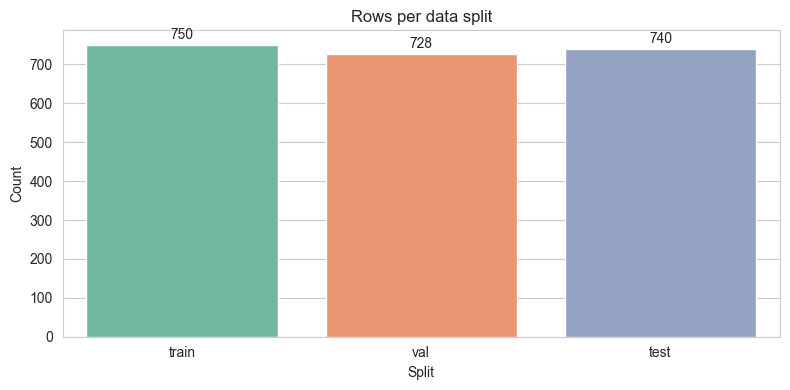

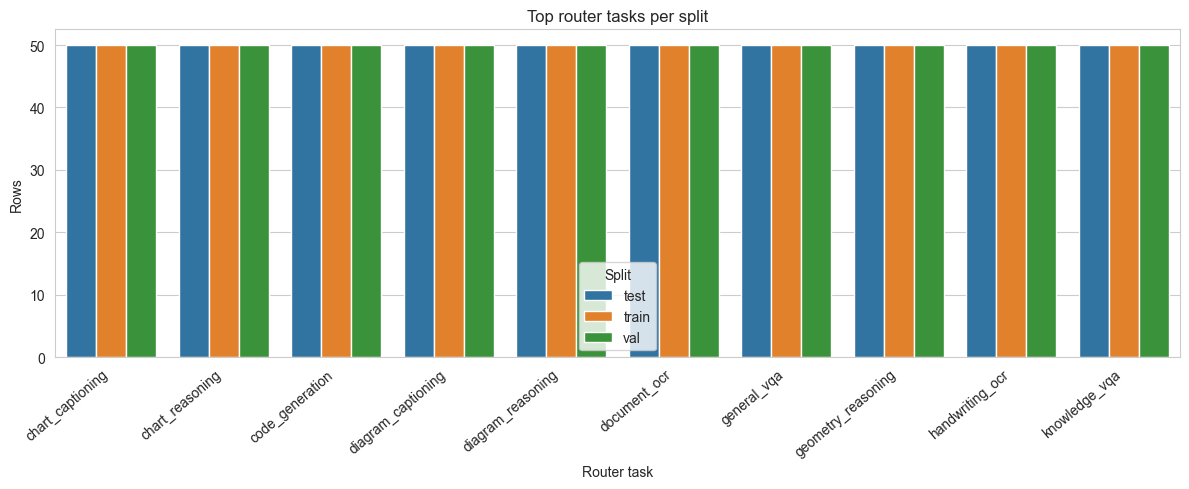

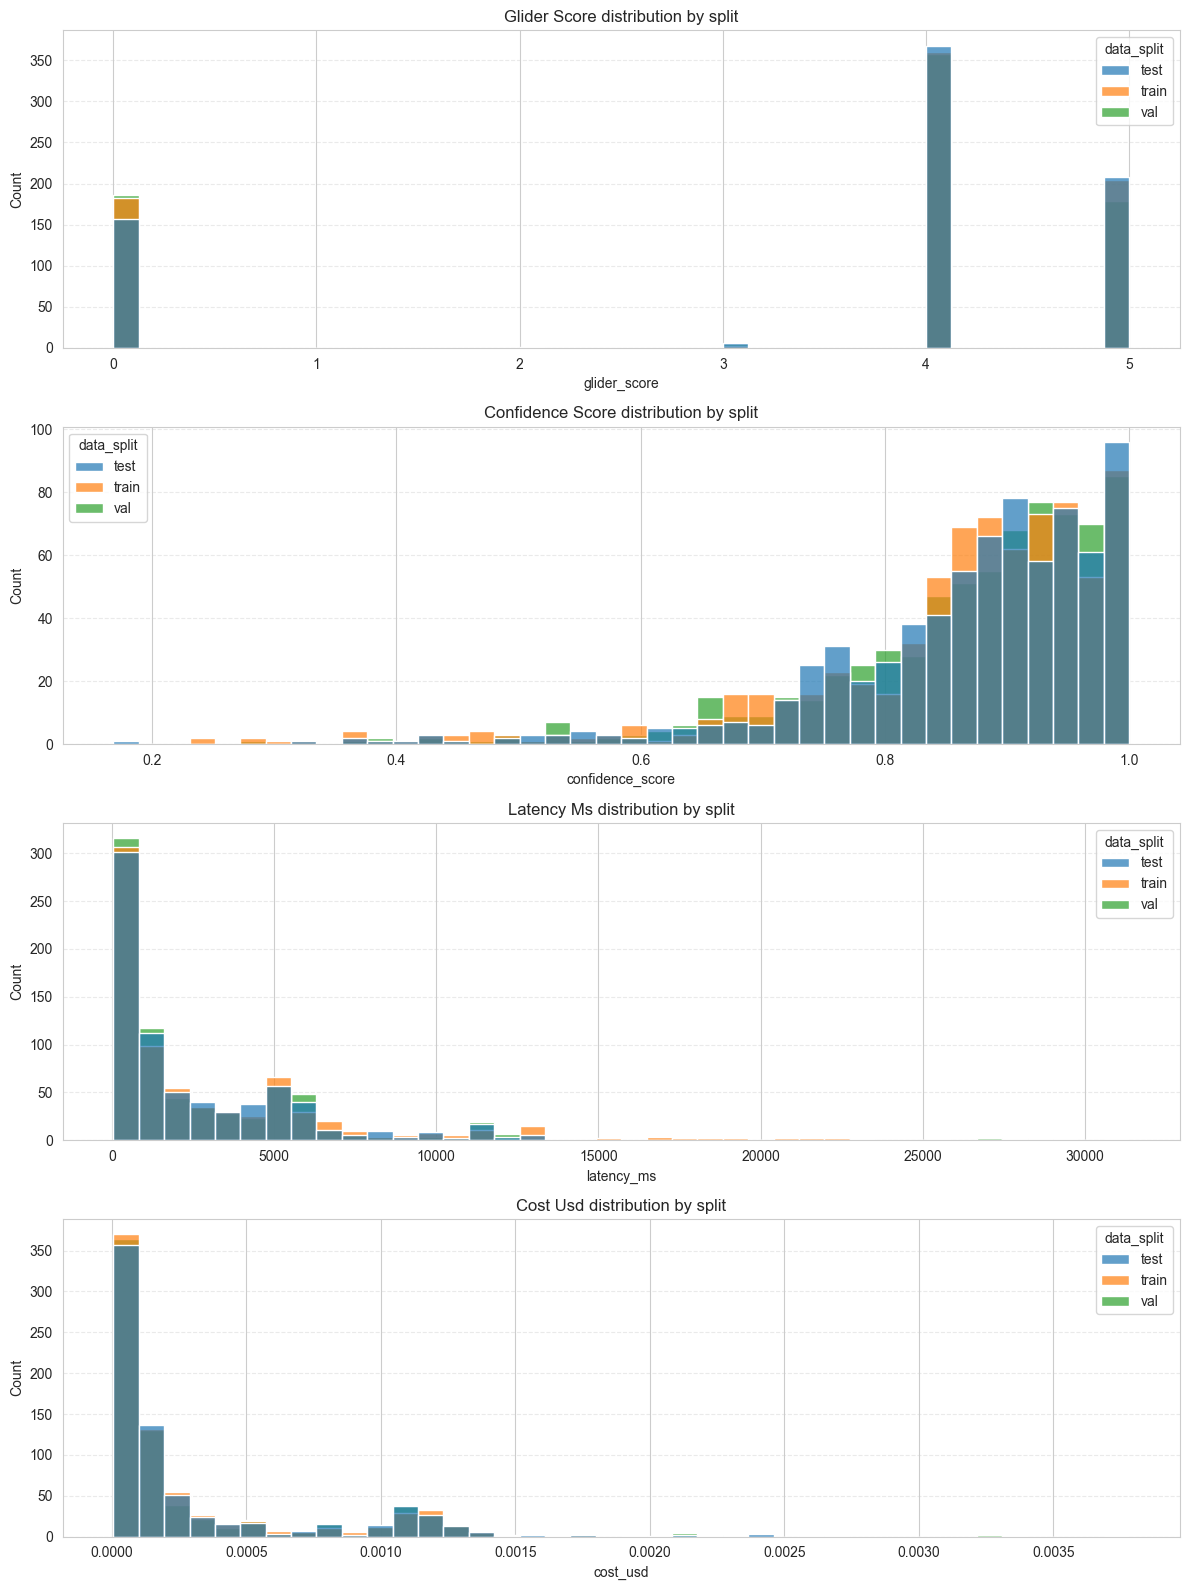

In [9]:
# Visualize split coverage and task/metric distributions
if 'data_split' not in df_clean.columns:
    print("⚠️  'data_split' column missing; skip visualization of splits.")
else:
    split_counts = df_clean['data_split'].value_counts()
    ordered_splits = ['train', 'val', 'test']
    ordered_splits += [split for split in split_counts.index if split not in ordered_splits]
    split_counts = split_counts.reindex(ordered_splits).fillna(0).astype(int)

    print("[Data split counts]")
    print(split_counts)

    fig, ax = plt.subplots(figsize=(8, 4))
    sns.barplot(x=split_counts.index, y=split_counts.values, palette='Set2', ax=ax)
    ax.set_title('Rows per data split')
    ax.set_ylabel('Count')
    ax.set_xlabel('Split')
    y_offset = split_counts.max() * 0.01 if split_counts.max() > 0 else 1
    for idx, value in enumerate(split_counts.values):
        ax.text(idx, value + y_offset, f"{value:,}", ha='center', va='bottom')
    plt.tight_layout()

    if 'router_task' in df_clean.columns:
        task_counts = df_clean['router_task'].value_counts()
        top_tasks = task_counts.head(10).index.tolist()
        print("Top router tasks (by rows):")
        print(task_counts.head(8))

        task_split_df = (
            df_clean[df_clean['router_task'].isin(top_tasks)]
            .groupby(['router_task', 'data_split'])
            .size()
            .reset_index(name='count')
        )

        fig, ax = plt.subplots(figsize=(12, 5))
        sns.barplot(
            data=task_split_df,
            x='router_task',
            y='count',
            hue='data_split',
            order=top_tasks,
            ax=ax,
        )
        ax.set_title('Top router tasks per split')
        ax.set_ylabel('Rows')
        ax.set_xlabel('Router task')
        ax.legend(title='Split')
        ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha='right')
        plt.tight_layout()
    else:
        print("⚠️  'router_task' column missing; skipping task-level chart.")

    metric_columns = [col for col in ['glider_score', 'confidence_score', 'latency_ms', 'cost_usd'] if col in df_clean.columns]
    if metric_columns:
        fig, axes = plt.subplots(len(metric_columns), 1, figsize=(12, 4 * len(metric_columns)), sharex=False)
        if len(metric_columns) == 1:
            axes = [axes]
        for col, ax in zip(metric_columns, axes):
            sns.histplot(
                data=df_clean,
                x=col,
                hue='data_split',
                multiple='layer',
                stat='count',
                bins=40,
                edgecolor='w',
                alpha=0.7,
                ax=ax,
            )
            ax.set_title(f"{col.replace('_', ' ').title()} distribution by split")
            ax.set_ylabel('Count')
            ax.grid(True, axis='y', linestyle='--', alpha=0.4)
        plt.tight_layout()
    else:
        print("⚠️  No numeric metrics found for histogram visualization.")


## 7. Save to Local SQLite Database

In [10]:
# Save to SQLite
print(f"\n{'='*80}")
print("SAVING TO LOCAL SQLITE DATABASE")
print(f"{'='*80}\n")

print(f"[Saving to SQLite]")
print(f"  Path: {LOCAL_DB_PATH}")
print(f"  Table: {TABLE_NAME}")
print(f"  Rows: {len(df_clean):,}")
print(f"  Columns: {len(df_clean.columns)}")
print()

save_to_sqlite(
    df=df_clean,
    db_path=LOCAL_DB_PATH,
    table_name=TABLE_NAME,
    if_exists='replace',
)

# Get file size
file_size_mb = LOCAL_DB_PATH.stat().st_size / (1024 * 1024)

print(f"\n{'='*80}")
print("SAVE COMPLETE")
print(f"{'='*80}")
print(f"  Database file: {LOCAL_DB_PATH}")
print(f"  File size: {file_size_mb:.2f} MB")
print(f"  Rows saved: {len(df_clean):,}")
print(f"  Table name: {TABLE_NAME}")
print(f"{'='*80}")

print(f"\n✓ Local database ready!")

2025-12-06 16:41:27,660 - db_utils - INFO - Created SQLite engine for ../data/vlm_router_cache.db
2025-12-06 16:41:27,661 - db_utils - INFO - Saving 2218 rows to ../data/vlm_router_cache.db:vlm_profiles
2025-12-06 16:41:27,678 - db_utils - INFO - ✓ Saved to ../data/vlm_router_cache.db



SAVING TO LOCAL SQLITE DATABASE

[Saving to SQLite]
  Path: ../data/vlm_router_cache.db
  Table: vlm_profiles
  Rows: 2,218
  Columns: 17


SAVE COMPLETE
  Database file: ../data/vlm_router_cache.db
  File size: 1.11 MB
  Rows saved: 2,218
  Table name: vlm_profiles

✓ Local database ready!


## 8. Verify Local Database

In [11]:
# Test loading from SQLite
print(f"\n{'='*80}")
print("VERIFYING LOCAL DATABASE")
print(f"{'='*80}\n")

print("[Loading from SQLite (verification)]")
df_verify = load_from_sqlite(
    db_path=LOCAL_DB_PATH,
    table_name=TABLE_NAME,
    limit=10,  # Just load 10 rows for verification
)

print(f"\n[Verification Results]")
print(f"  Loaded {len(df_verify)} rows (limit=10)")
print(f"  Columns match: {set(df_verify.columns) == set(df_clean.columns)}")

print(f"\n[Sample Data]")
display(df_verify.head())

print(f"\n✓ Local database verified successfully!")

2025-12-06 16:41:27,682 - db_utils - INFO - Created SQLite engine for ../data/vlm_router_cache.db
2025-12-06 16:41:27,683 - db_utils - INFO - Loading from ../data/vlm_router_cache.db:vlm_profiles
2025-12-06 16:41:27,683 - db_utils - INFO -   Limit: 10
2025-12-06 16:41:27,684 - db_utils - INFO - Loaded 10 rows
2025-12-06 16:41:27,684 - db_utils - INFO -   Unique samples: 3
2025-12-06 16:41:27,685 - db_utils - INFO -   Unique models: 5
2025-12-06 16:41:27,685 - db_utils - INFO -   Data splits: {'test': 10}



VERIFYING LOCAL DATABASE

[Loading from SQLite (verification)]

[Verification Results]
  Loaded 10 rows (limit=10)
  Columns match: True

[Sample Data]


,sample_id,source_config,source_dataset,router_task,data_split,prompt_raw,txt_prompt_length_chars,txt_prompt_length_words,img_width,img_height,img_aspect_ratio,model_name,model_prefix,latency_ms,cost_usd,confidence_score,glider_score
0,chart2text_0_68249402,chart2text,cauldron,chart_captioning,test,Could you shed some light on the insights conv...,65,12,800,776,1.030928,qwen2_5_vl_7b,m3,8598.0,0.000246,0.760264,4.0
1,chart2text_0_68249402,chart2text,cauldron,chart_captioning,test,Could you shed some light on the insights conv...,65,12,800,776,1.030928,gemma_3_27b,m5,10272.0,0.000097,0.832087,5.0
2,chart2text_0_68249402,chart2text,cauldron,chart_captioning,test,Could you shed some light on the insights conv...,65,12,800,776,1.030928,deepseek_ocr,m1,1254.0,0.000037,0.996436,0.0
3,chart2text_0_68249402,chart2text,cauldron,chart_captioning,test,Could you shed some light on the insights conv...,65,12,800,776,1.030928,qwen3_vl_8b_thinking,m4,5033.0,0.001188,0.865371,4.0
4,chart2text_0_68249402,chart2text,cauldron,chart_captioning,test,Could you shed some light on the insights conv...,65,12,800,776,1.030928,qwen2_5_vl_3b,m2,6152.0,0.000098,0.831460,4.0



✓ Local database verified successfully!


## 9. Test Loading by Split

In [12]:
# Test loading each split
if 'data_split' in df_clean.columns:
    print(f"\n{'='*80}")
    print("TESTING SPLIT LOADING")
    print(f"{'='*80}\n")

    for split in ['train', 'val', 'test']:
        print(f"[Loading {split} split]")
        df_split = load_from_sqlite(
            db_path=LOCAL_DB_PATH,
            table_name=TABLE_NAME,
            data_split=split,
            limit=5,
        )
        print(f"  ✓ Loaded {len(df_split)} rows (limit=5)")
        print()

    print(f"✓ All splits can be loaded successfully!")
else:
    print(f"\nSkipping split loading test (no data_split column)")

2025-12-06 16:41:27,694 - db_utils - INFO - Created SQLite engine for ../data/vlm_router_cache.db
2025-12-06 16:41:27,694 - db_utils - INFO - Loading from ../data/vlm_router_cache.db:vlm_profiles
2025-12-06 16:41:27,694 - db_utils - INFO -   Filtering by data_split: train
2025-12-06 16:41:27,694 - db_utils - INFO -   Limit: 5
2025-12-06 16:41:27,696 - db_utils - INFO - Loaded 5 rows
2025-12-06 16:41:27,696 - db_utils - INFO -   Unique samples: 2
2025-12-06 16:41:27,696 - db_utils - INFO -   Unique models: 4
2025-12-06 16:41:27,697 - db_utils - INFO -   Data splits: {'train': 5}
2025-12-06 16:41:27,697 - db_utils - INFO - Created SQLite engine for ../data/vlm_router_cache.db
2025-12-06 16:41:27,697 - db_utils - INFO - Loading from ../data/vlm_router_cache.db:vlm_profiles
2025-12-06 16:41:27,697 - db_utils - INFO -   Filtering by data_split: val
2025-12-06 16:41:27,697 - db_utils - INFO -   Limit: 5
2025-12-06 16:41:27,699 - db_utils - INFO - Loaded 5 rows
2025-12-06 16:41:27,699 - db_ut


TESTING SPLIT LOADING

[Loading train split]
  ✓ Loaded 5 rows (limit=5)

[Loading val split]
  ✓ Loaded 5 rows (limit=5)

[Loading test split]
  ✓ Loaded 5 rows (limit=5)

✓ All splits can be loaded successfully!


## 10. Create Metadata File

In [13]:
# Save metadata about the database
import json

metadata = {
    'created_at': datetime.now().isoformat(),
    'source_host': db_config.host,
    'source_database': db_config.name,
    'total_rows': int(len(df_clean)),
    'unique_samples': int(df_clean['sample_id'].nunique()),
    'unique_models': int(df_clean['model_name'].nunique()),
    'models': sorted(df_clean['model_name'].unique().tolist()),
    'columns': df_clean.columns.tolist(),
    'table_name': TABLE_NAME,
    'cleaning_stats': cleaning_stats,
}

if 'data_split' in df_clean.columns:
    metadata['split_counts'] = df_clean['data_split'].value_counts().to_dict()

metadata_path = DATA_DIR / "vlm_router_cache_metadata.json"
with open(metadata_path, 'w') as f:
    json.dump(metadata, f, indent=2)

print(f"\n[Metadata Saved]")
print(f"  Path: {metadata_path}")
print(f"\nMetadata:")
print(json.dumps(metadata, indent=2))


[Metadata Saved]
  Path: ../data/vlm_router_cache_metadata.json

Metadata:
{
  "created_at": "2025-12-06T16:41:27.706650",
  "source_host": "localhost",
  "source_database": "vlmrouter",
  "total_rows": 2218,
  "unique_samples": 570,
  "unique_models": 5,
  "models": [
    "deepseek_ocr",
    "gemma_3_27b",
    "qwen2_5_vl_3b",
    "qwen2_5_vl_7b",
    "qwen3_vl_8b_thinking"
  ],
  "columns": [
    "sample_id",
    "source_config",
    "source_dataset",
    "router_task",
    "data_split",
    "prompt_raw",
    "txt_prompt_length_chars",
    "txt_prompt_length_words",
    "img_width",
    "img_height",
    "img_aspect_ratio",
    "model_name",
    "model_prefix",
    "latency_ms",
    "cost_usd",
    "confidence_score",
    "glider_score"
  ],
  "table_name": "vlm_profiles",
  "cleaning_stats": {
    "initial_rows": 2218,
    "dropped_rows": 0,
    "filled_cost": 0,
    "filled_latency": 0,
    "filled_confidence": 0,
    "final_rows": 2218
  },
  "split_counts": {
    "train": 750,
 

## 11. Usage Instructions

In [14]:
# Print usage instructions
print(f"\n{'='*80}")
print("SETUP COMPLETE - HOW TO USE")
print(f"{'='*80}\n")

print("The local database is ready! In your training notebooks (02, 03, 04), replace:")
print()
print("  # OLD: Load from PostgreSQL")
print("  df_profiles = load_profiles_real_schema(")
print("      db_config=db_config,")
print("      data_split='train',")
print("  )")
print()
print("  # NEW: Load from local SQLite")
print("  from db_utils import load_from_sqlite")
print()
print(f"  LOCAL_DB_PATH = Path('../data/vlm_router_cache.db')")
print()
print("  df_profiles = load_from_sqlite(")
print("      db_path=LOCAL_DB_PATH,")
print("      table_name='vlm_profiles',")
print("      data_split='train',  # or 'val', 'test', or None for all")
print("  )")
print()
print(f"{'='*80}")
print(f"\n✓ You can now run notebooks 02, 03, 04 using the local database!")
print(f"\n💡 Tip: Re-run this notebook whenever you want to refresh the local cache.")
print(f"{'='*80}")


SETUP COMPLETE - HOW TO USE

The local database is ready! In your training notebooks (02, 03, 04), replace:

  # OLD: Load from PostgreSQL
  df_profiles = load_profiles_real_schema(
      db_config=db_config,
      data_split='train',
  )

  # NEW: Load from local SQLite
  from db_utils import load_from_sqlite

  LOCAL_DB_PATH = Path('../data/vlm_router_cache.db')

  df_profiles = load_from_sqlite(
      db_path=LOCAL_DB_PATH,
      table_name='vlm_profiles',
      data_split='train',  # or 'val', 'test', or None for all
  )


✓ You can now run notebooks 02, 03, 04 using the local database!

💡 Tip: Re-run this notebook whenever you want to refresh the local cache.


## Summary

This notebook:
1. ✅ Connected to PostgreSQL
2. ✅ Fetched all profiling data
3. ✅ Validated data quality
4. ✅ Cleaned missing values
5. ✅ Validated train/val/test splits
6. ✅ Visualized split coverage and key metrics
7. ✅ Saved to local SQLite database
8. ✅ Verified the local database works

### Files Created

- `../data/vlm_router_cache.db` - Local SQLite database with all data
- `../data/vlm_router_cache_metadata.json` - Metadata about the cache

### Next Steps

1. Update notebooks 02, 03, 04 to use `load_from_sqlite()` instead of `load_profiles_real_schema()`
2. Run training notebooks - they'll be much faster!
3. Re-run this notebook whenever you need to refresh the cache with new data
